In [1]:
#imports
import pandas as pd
import numpy as np
import os 
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
input_dir= "../../Cleaned_Data"


In [3]:
climate_df= pd.read_csv(os.path.join(input_dir,"climate_2024_imputed.csv"))
soil_df= pd.read_csv(os.path.join(input_dir,"soil_properties_imputed.csv"))

In [4]:
soil_df.columns

Index(['y', 'x', 'HWSD2_SMU_ID', 'COARSE', 'SAND', 'SILT', 'CLAY', 'BULK',
       'REF_BULK', 'ORG_CARBON', 'PH_WATER', 'TOTAL_N', 'CEC_SOIL', 'CEC_CLAY',
       'CEC_EFF', 'TEB', 'BSAT', 'ALUM_SAT', 'ESP', 'TCARBON_EQ', 'GYPSUM',
       'ELEC_COND'],
      dtype='object')

Soil GeoDataFrame with polygon geometry: (23262, 23)
Geometry types: ['Polygon']


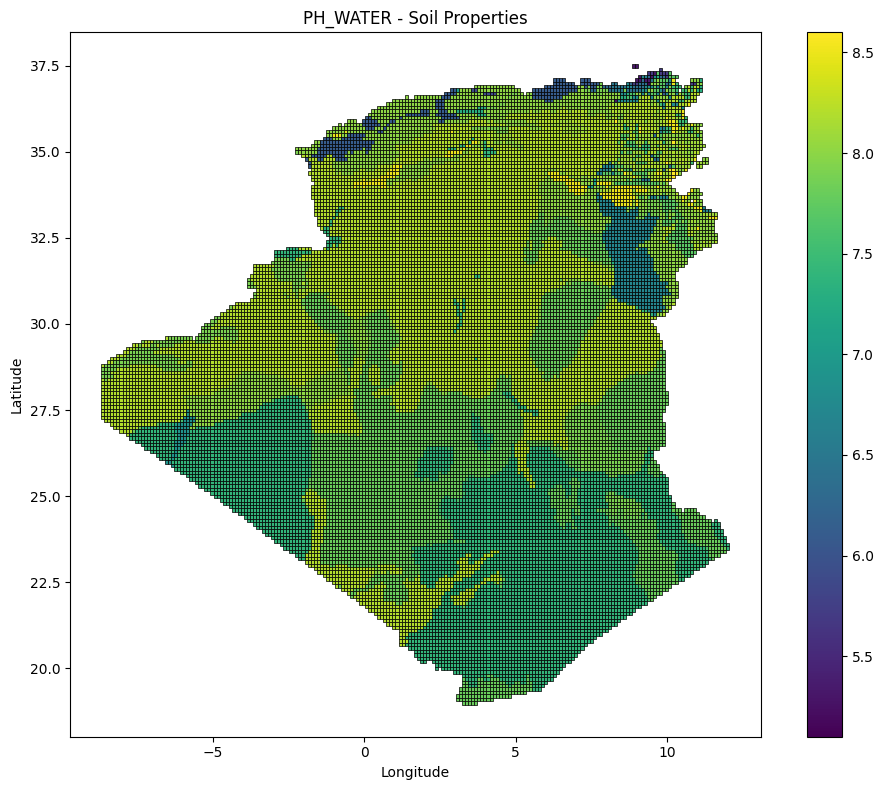

In [5]:
# Load soil spatial grid with polygon geometries
soil_grid_path = "../../ExtractedDatasets/SoilFeatures/hwsd2_grid01_D1.gpkg"
soil_grid = gpd.read_file(soil_grid_path)

# Create temporary point geometries from soil_df to match with grid
soil_temp = gpd.GeoDataFrame(
    soil_df,
    geometry=gpd.points_from_xy(soil_df['x'], soil_df['y']),
    crs=soil_grid.crs
)

# Spatial join to find which polygon each point belongs to
df_soil_joined = gpd.sjoin(soil_temp, soil_grid[['geometry']], how='left', predicate='within')

# Replace point geometry with the polygon geometry
# Get unique index mappings
idx_mapping = {}
for idx in df_soil_joined.index:
    if 'index_right' in df_soil_joined.columns and pd.notna(df_soil_joined.loc[idx, 'index_right']):
        grid_idx = int(df_soil_joined.loc[idx, 'index_right'])
        idx_mapping[idx] = soil_grid.iloc[grid_idx]['geometry']

# Assign polygon geometries
for idx, geom in idx_mapping.items():
    df_soil_joined.loc[idx, 'geometry'] = geom

# Drop temporary columns and convert to GeoDataFrame with polygon geometry
df_soil = df_soil_joined.drop(columns=['index_right'], errors='ignore')
df_soil = gpd.GeoDataFrame(df_soil, geometry='geometry', crs=soil_grid.crs)

print(f"Soil GeoDataFrame with polygon geometry: {df_soil.shape}")
print(f"Geometry types: {df_soil.geometry.type.unique()}")

# Plot PH_WATER if available
if 'PH_WATER' in df_soil.columns:
    fig, ax = plt.subplots(figsize=(10, 8))
    df_soil.plot(column='PH_WATER', ax=ax, legend=True, cmap='viridis', edgecolor='black', linewidth=0.5)
    ax.set_title('PH_WATER - Soil Properties')
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.tight_layout()
    plt.show()
else:
    print("Column 'PH_WATER' not found in df_soil.columns")


In [6]:
# Load climate spatial grid with polygon geometries
climate_grid_path = "../../ExtractedDatasets/ClimateFeatures/grid_0p1.gpkg"
climate_grid = gpd.read_file(climate_grid_path, layer="grid")

print(f"Climate grid shape: {climate_grid.shape}")
print(f"Climate grid CRS: {climate_grid.crs}")
print(f"Climate grid columns: {climate_grid.columns.tolist()}")

# Merge climate data with grid using cell_id to get polygon geometries
climate_gdf = climate_grid[['cell_id', 'geometry']].merge(climate_df, on='cell_id', how='right')

# Convert to GeoDataFrame with polygon geometry
climate_gdf = gpd.GeoDataFrame(climate_gdf, geometry='geometry', crs=climate_grid.crs)

print(f"\nClimate GeoDataFrame with polygon geometry: {climate_gdf.shape}")
print(f"Geometry types: {climate_gdf.geometry.type.unique()}")
print(f"Columns: {climate_gdf.columns.tolist()}")
climate_gdf.head()


Climate grid shape: (23322, 2)
Climate grid CRS: EPSG:4326
Climate grid columns: ['cell_id', 'geometry']

Climate GeoDataFrame with polygon geometry: (23322, 14)
Geometry types: ['MultiPolygon']
Columns: ['cell_id', 'geometry', 'month_1', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12']


,cell_id,geometry,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,0,"MULTIPOLYGON (((-8.56891 27.26815, -8.56891 27...","[np.float64(8.5), np.float64(22.0), np.float64...","[np.float64(11.0), np.float64(25.0), np.float6...","[np.float64(13.0), np.float64(27.0), np.float6...","[np.float64(18.0), np.float64(32.0), np.float6...","[np.float64(20.0), np.float64(33.75), np.float...","[np.float64(23.0), np.float64(36.75), np.float...","[np.float64(27.75), np.float64(42.0), np.float...","[np.float64(27.0), np.float64(41.0), np.float6...","[np.float64(23.0), np.float64(36.0), np.float6...","[np.float64(18.0), np.float64(31.0), np.float6...","[np.float64(14.0), np.float64(27.0), np.float6...","[np.float64(8.0), np.float64(22.0), np.float64..."
1,1,"MULTIPOLYGON (((-8.56891 27.36815, -8.56891 27...","[np.float64(8.0), np.float64(22.0), np.float64...","[np.float64(11.0), np.float64(25.0), np.float6...","[np.float64(13.0), np.float64(27.0), np.float6...","[np.float64(18.0), np.float64(32.0), np.float6...","[np.float64(19.25), np.float64(33.25), np.floa...","[np.float64(22.75), np.float64(36.25), np.floa...","[np.float64(27.0), np.float64(41.75), np.float...","[np.float64(27.0), np.float64(41.0), np.float6...","[np.float64(23.0), np.float64(36.0), np.float6...","[np.float64(18.0), np.float64(31.0), np.float6...","[np.float64(14.0), np.float64(27.0), np.float6...","[np.float64(8.0), np.float64(21.75), np.float6..."
2,2,"MULTIPOLYGON (((-8.56891 27.46815, -8.56891 27...","[np.float64(8.5), np.float64(22.0), np.float64...","[np.float64(11.0), np.float64(24.75), np.float...","[np.float64(13.0), np.float64(27.0), np.float6...","[np.float64(17.5), np.float64(31.5), np.float6...","[np.float64(19.0), np.float64(33.0), np.float6...","[np.float64(22.0), np.float64(36.0), np.float6...","[np.float64(27.0), np.float64(41.5), np.float6...","[np.float64(27.0), np.float64(41.0), np.float6...","[np.float64(22.75), np.float64(36.0), np.float...","[np.float64(18.0), np.float64(31.0), np.float6...","[np.float64(13.5), np.float64(27.0), np.float6...","[np.float64(8.0), np.float64(21.25), np.float6..."
3,3,"MULTIPOLYGON (((-8.56891 27.56815, -8.56891 27...","[np.float64(8.0), np.float64(22.0), np.float64...","[np.float64(10.75), np.float64(24.0), np.float...","[np.float64(13.0), np.float64(27.0), np.float6...","[np.float64(17.0), np.float64(31.0), np.float6...","[np.float64(19.0), np.float64(33.0), np.float6...","[np.float64(22.0), np.float64(36.0), np.float6...","[np.float64(27.0), np.float64(41.0), np.float6...","[np.float64(26.75), np.float64(41.0), np.float...","[np.float64(22.0), np.float64(36.0), np.float6...","[np.float64(18.0), np.float64(31.0), np.float6...","[np.float64(13.0), np.float64(27.0), np.float6...","[np.float64(8.0), np.float64(21.0), np.float64..."
4,4,"MULTIPOLYGON (((-8.56891 27.66815, -8.56891 27...","[np.float64(8.0), np.float64(22.0), np.float64...","[np.float64(10.0), np.float64(24.0), np.float6...","[np.float64(12.5), np.float64(27.0), np.float6...","[np.float64(17.0), np.float64(31.0), np.float6...","[np.float64(19.0), np.float64(33.0), np.float6...","[np.float64(22.0), np.float64(36.0), np.float6...","[np.float64(27.0), np.float64(41.0), np.float6...","[np.float64(26.25), np.float64(41.0), np.float...","[np.float64(22.0), np.float64(36.0), np.float6...","[np.float64(18.0), np.float64(31.0), np.float6...","[np.float64(13.0), np.float64(26.0), np.float6...","[np.float64(8.0), np.float64(21.0), np.float64..."


In [7]:
# Add x (longitude) and y (latitude) columns to GeoDataFrames
# Use representative_point() instead of centroid to avoid warnings in geographic CRS

# Function to add x,y columns safely

def add_lon_lat(gdf, geom_col='geometry', lon_name='x', lat_name='y'):
    # representative_point returns a point guaranteed to lie within the polygon
    pts = gdf[geom_col].representative_point()
    gdf[lon_name] = pts.x
    gdf[lat_name] = pts.y
    return gdf

#add column x and y in climate_df
climate_gdf = add_lon_lat(climate_gdf, geom_col='geometry', lon_name='x', lat_name='y')
print(f"\nClimate GeoDataFrame with x,y columns: {climate_gdf[['x', 'y']].head()}")
print("shape:", climate_gdf.shape)


Climate GeoDataFrame with x,y columns:           x          y
0 -8.574054  27.262808
1 -8.618508  27.341545
2 -8.618494  27.423112
3 -8.618481  27.495017
4 -8.618457  27.631494
shape: (23322, 16)


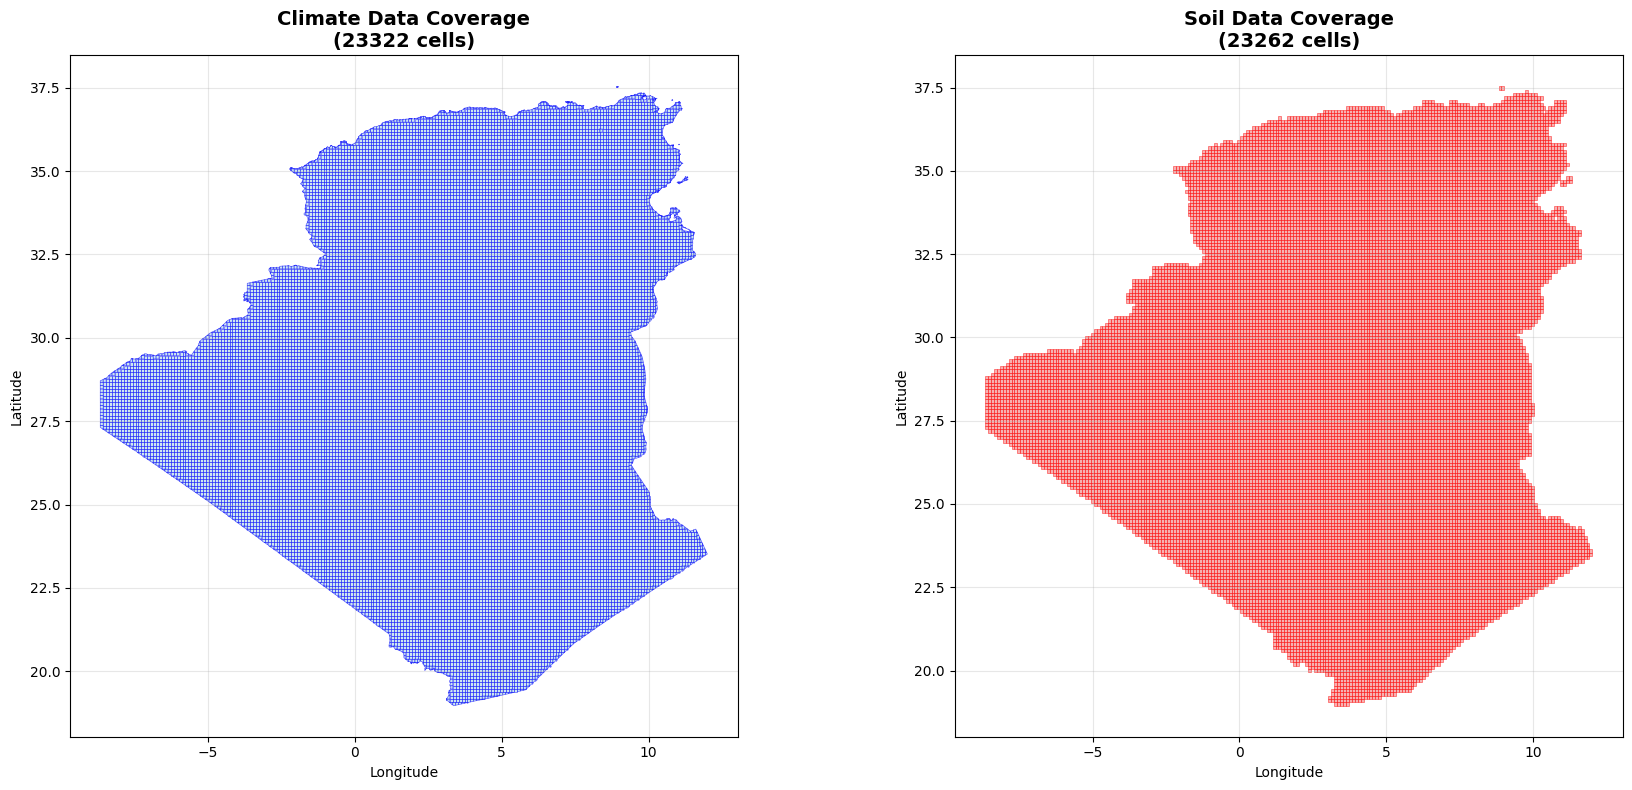

Climate coverage: 23322 polygons
Soil coverage: 23262 polygons
Climate CRS: EPSG:4326
Soil CRS: EPSG:4326


In [8]:
# Plot coverage maps for climate and soil data
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot climate coverage
ax1 = axes[0]
climate_gdf.plot(ax=ax1, color='lightblue', edgecolor='blue', linewidth=0.5, alpha=0.6)
ax1.set_title(f'Climate Data Coverage\n({len(climate_gdf)} cells)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.grid(True, alpha=0.3)

# Plot soil coverage
ax2 = axes[1]
df_soil.plot(ax=ax2, color='lightcoral', edgecolor='red', linewidth=0.5, alpha=0.6)
ax2.set_title(f'Soil Data Coverage\n({len(df_soil)} cells)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Climate coverage: {len(climate_gdf)} polygons")
print(f"Soil coverage: {len(df_soil)} polygons")
print(f"Climate CRS: {climate_gdf.crs}")
print(f"Soil CRS: {df_soil.crs}")


Polygons only in climate: 23322
Polygons only in soil: 23262
Common polygons: 0


C:\Users\E15\AppData\Local\Temp\ipykernel_10324\3739574928.py:43: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax3.legend()
C:\Users\E15\AppData\Local\Temp\ipykernel_10324\3739574928.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend()


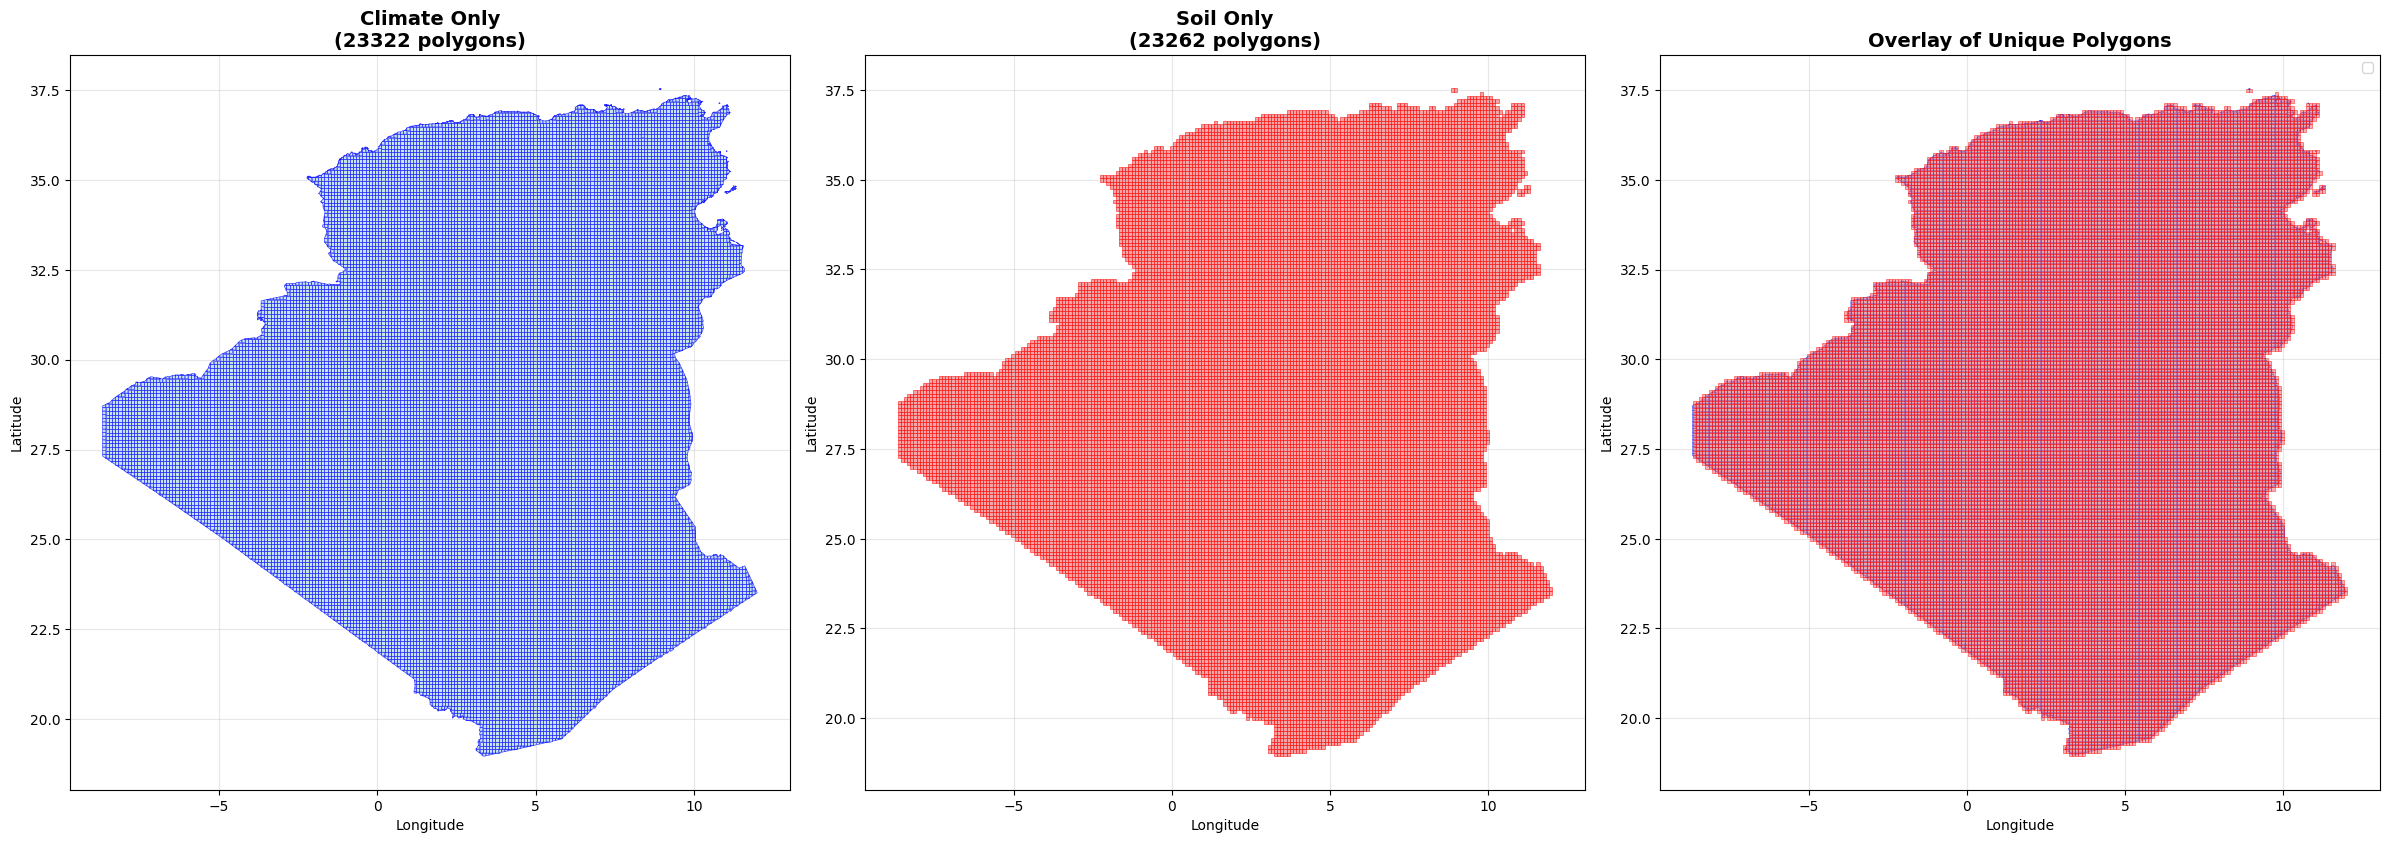

In [9]:
# Extract unique polygons from each dataset
# Polygons in climate but not in soil
climate_only = climate_gdf[~climate_gdf.geometry.isin(df_soil.geometry)]

# Polygons in soil but not in climate
soil_only = df_soil[~df_soil.geometry.isin(climate_gdf.geometry)]

print(f"Polygons only in climate: {len(climate_only)}")
print(f"Polygons only in soil: {len(soil_only)}")
print(f"Common polygons: {len(climate_gdf) - len(climate_only)}")

# Plot the unique polygons
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Plot 1: Polygons only in climate (not in soil)
ax1 = axes[0]
if len(climate_only) > 0:
    climate_only.plot(ax=ax1, color='lightblue', edgecolor='blue', linewidth=0.5, alpha=0.7)
ax1.set_title(f'Climate Only\n({len(climate_only)} polygons)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.grid(True, alpha=0.3)

# Plot 2: Polygons only in soil (not in climate)
ax2 = axes[1]
if len(soil_only) > 0:
    soil_only.plot(ax=ax2, color='lightcoral', edgecolor='red', linewidth=0.5, alpha=0.7)
ax2.set_title(f'Soil Only\n({len(soil_only)} polygons)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.grid(True, alpha=0.3)

# Plot 3: Overlay showing both unique sets
ax3 = axes[2]
if len(climate_only) > 0:
    climate_only.plot(ax=ax3, color='lightblue', edgecolor='blue', linewidth=0.5, alpha=0.6, label='Climate only')
if len(soil_only) > 0:
    soil_only.plot(ax=ax3, color='lightcoral', edgecolor='red', linewidth=0.5, alpha=0.6, label='Soil only')
ax3.set_title('Overlay of Unique Polygons', fontsize=14, fontweight='bold')
ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')
ax3.grid(True, alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.show()


Polygons only in climate (no spatial intersection with soil): 2
Polygons only in soil (no spatial intersection with climate): 0
Climate polygons with soil intersection: 23320
Soil polygons with climate intersection: 23262


C:\Users\E15\AppData\Local\Temp\ipykernel_10324\2498678324.py:53: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax3.legend(loc='upper right')
C:\Users\E15\AppData\Local\Temp\ipykernel_10324\2498678324.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend(loc='upper right')


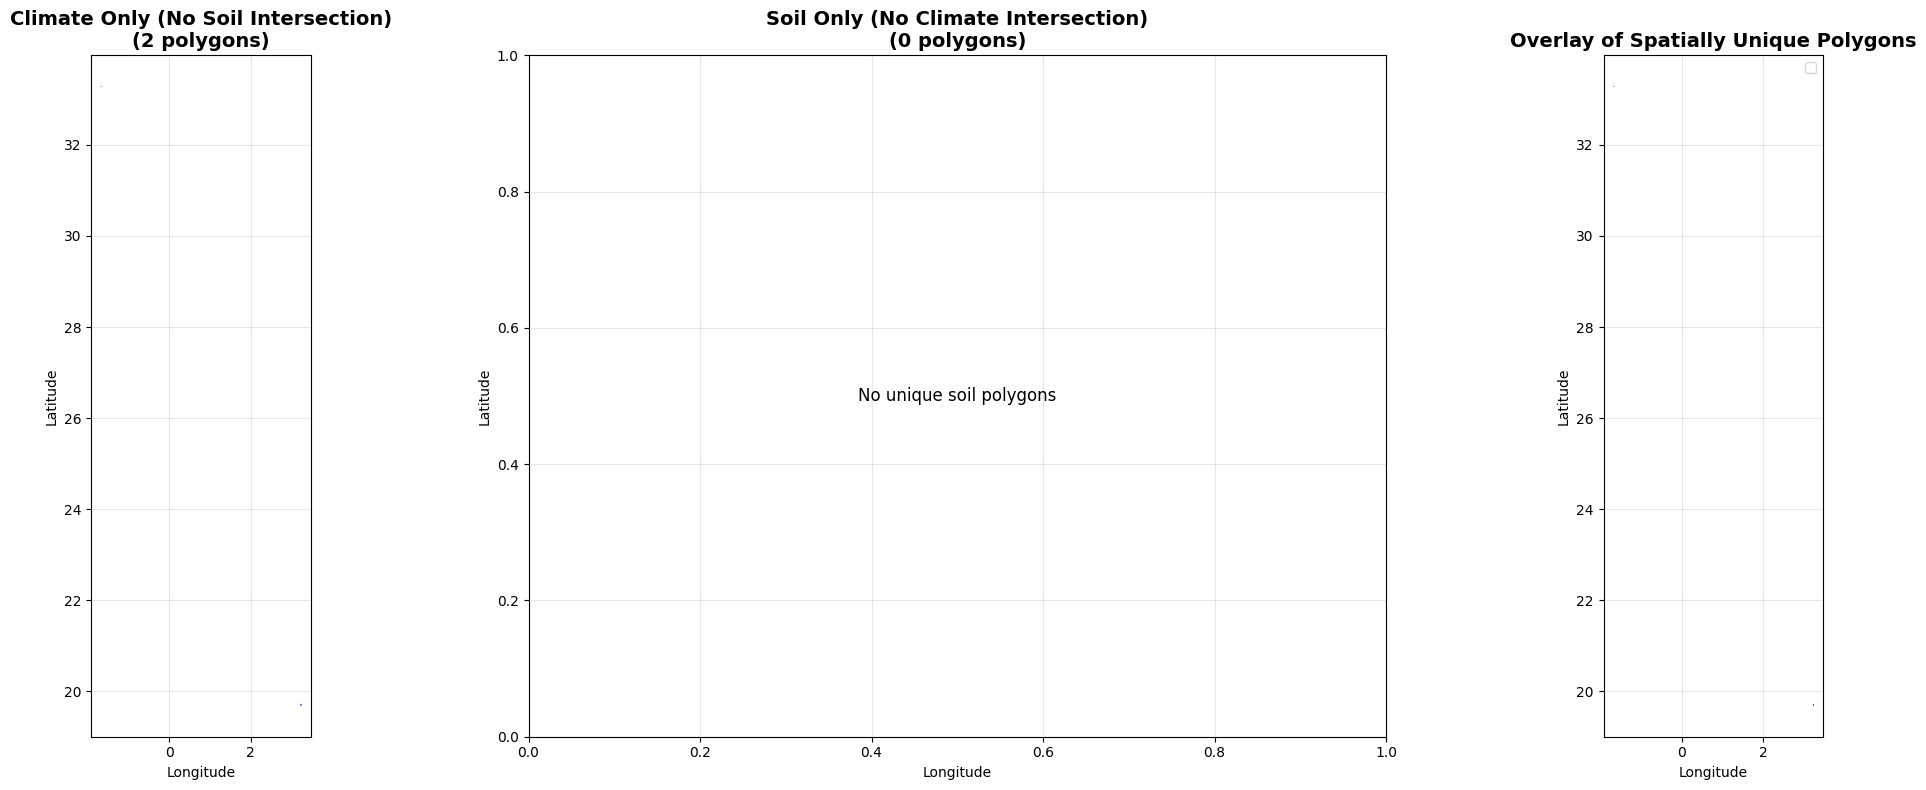

In [10]:
# Use spatial intersection to find truly unique polygons
# Perform spatial join to find which climate polygons intersect with soil polygons
climate_with_soil = gpd.sjoin(climate_gdf, df_soil[['geometry']], how='left', predicate='intersects')
soil_with_climate = gpd.sjoin(df_soil, climate_gdf[['geometry']], how='left', predicate='intersects')

# Polygons that don't have a match (index_right is NaN)
climate_only_spatial = climate_gdf.loc[climate_with_soil[climate_with_soil['index_right'].isna()].index]
soil_only_spatial = df_soil.loc[soil_with_climate[soil_with_climate['index_right'].isna()].index]

print(f"Polygons only in climate (no spatial intersection with soil): {len(climate_only_spatial)}")
print(f"Polygons only in soil (no spatial intersection with climate): {len(soil_only_spatial)}")
print(f"Climate polygons with soil intersection: {len(climate_gdf) - len(climate_only_spatial)}")
print(f"Soil polygons with climate intersection: {len(df_soil) - len(soil_only_spatial)}")

# Plot the spatially unique polygons
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Plot 1: Polygons only in climate (no spatial intersection)
ax1 = axes[0]
if len(climate_only_spatial) > 0:
    climate_only_spatial.plot(ax=ax1, color='darkblue', edgecolor='blue', linewidth=0.8, alpha=0.8)
else:
    ax1.text(0.5, 0.5, 'No unique climate polygons', ha='center', va='center', transform=ax1.transAxes, fontsize=12)
ax1.set_title(f'Climate Only (No Soil Intersection)\n({len(climate_only_spatial)} polygons)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.grid(True, alpha=0.3)

# Plot 2: Polygons only in soil (no spatial intersection)
ax2 = axes[1]
if len(soil_only_spatial) > 0:
    soil_only_spatial.plot(ax=ax2, color='darkred', edgecolor='red', linewidth=0.8, alpha=0.8)
else:
    ax2.text(0.5, 0.5, 'No unique soil polygons', ha='center', va='center', transform=ax2.transAxes, fontsize=12)
ax2.set_title(f'Soil Only (No Climate Intersection)\n({len(soil_only_spatial)} polygons)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.grid(True, alpha=0.3)

# Plot 3: Overlay showing both unique sets
ax3 = axes[2]
if len(climate_only_spatial) > 0:
    climate_only_spatial.plot(ax=ax3, color='darkblue', edgecolor='blue', linewidth=0.8, alpha=0.7, label=f'Climate only ({len(climate_only_spatial)})')
if len(soil_only_spatial) > 0:
    soil_only_spatial.plot(ax=ax3, color='darkred', edgecolor='red', linewidth=0.8, alpha=0.7, label=f'Soil only ({len(soil_only_spatial)})')
if len(climate_only_spatial) == 0 and len(soil_only_spatial) == 0:
    ax3.text(0.5, 0.5, 'All polygons have spatial overlap', ha='center', va='center', transform=ax3.transAxes, fontsize=12)
ax3.set_title('Overlay of Spatially Unique Polygons', fontsize=14, fontweight='bold')
ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')
ax3.grid(True, alpha=0.3)
if len(climate_only_spatial) > 0 or len(soil_only_spatial) > 0:
    ax3.legend(loc='upper right')

plt.tight_layout()
plt.show()


In [13]:
# Centroid-based merge (exact and nearest fallback)
# Steps:
# 1. Reproject to metric CRS for accurate distance (EPSG:3857)
# 2. Compute centroids for climate and soil polygons
# 3. Create exact matches using rounded centroid coordinates (e.g., 5 decimal places)
# 4. For unmatched climate centroids, find nearest soil centroid (KDTree)
# 5. Build final merged GeoDataFrame with match_type and distance_m

from scipy.spatial import cKDTree

# Helper: add centroid lon/lat (4326) and keep geometry intact

def compute_centroids(gdf, lon_col='centroid_lon', lat_col='centroid_lat'):
    if gdf.crs is None:
        raise ValueError("GeoDataFrame CRS is None; cannot compute centroids.")
    # Use representative point for lon/lat in 4326 (guaranteed inside)
    reps = gdf.geometry.representative_point()
    gdf[lon_col] = reps.x
    gdf[lat_col] = reps.y
    return gdf

# Prepare copies
climate_centroid = compute_centroids(climate_gdf.copy())
soil_centroid = compute_centroids(df_soil.copy())

# Exact match: rounded lon/lat key (in degrees)
precision = 6  # ~0.11 meters at equator per 1e-6 degree
climate_centroid['key'] = climate_centroid['centroid_lon'].round(precision).astype(str) + ":" + climate_centroid['centroid_lat'].round(precision).astype(str)
soil_centroid['key'] = soil_centroid['centroid_lon'].round(precision).astype(str) + ":" + soil_centroid['centroid_lat'].round(precision).astype(str)

# Map key -> soil index
soil_key_to_idx = (
    soil_centroid.reset_index()
    .rename(columns={'index':'soil_idx'})[['soil_idx','key']]
    .drop_duplicates(subset='key')
    .set_index('key')['soil_idx']
)

# Build KDTree on projected centroids for nearest search
soil_proj = df_soil.to_crs(3857)
soil_cent_xy = np.vstack([soil_proj.geometry.centroid.x, soil_proj.geometry.centroid.y]).T
soil_tree = cKDTree(soil_cent_xy)

climate_proj = climate_gdf.to_crs(3857)
climate_cent_xy = np.vstack([climate_proj.geometry.centroid.x, climate_proj.geometry.centroid.y]).T

exact_matches = []  # (climate_idx, soil_idx)
nearest_matches = []  # (climate_idx, soil_idx, dist_m)

for pos, clim_idx in enumerate(climate_centroid.index):
    key = climate_centroid.at[clim_idx, 'key']
    if key in soil_key_to_idx.index:
        soil_idx = int(soil_key_to_idx.loc[key])
        exact_matches.append((clim_idx, soil_idx))
    else:
        dist, soil_pos = soil_tree.query(climate_cent_xy[pos])
        soil_idx = int(df_soil.index[soil_pos])
        nearest_matches.append((clim_idx, soil_idx, float(dist)))

# DataFrames for mappings
exact_df = pd.DataFrame(exact_matches, columns=['climate_idx','soil_idx'])
exact_df['match_type'] = 'exact'
exact_df['distance_m'] = 0.0

nearest_df = pd.DataFrame(nearest_matches, columns=['climate_idx','soil_idx','distance_m'])
nearest_df['match_type'] = 'nearest'

mapping_df = pd.concat([exact_df, nearest_df], ignore_index=True)

# Merge attributes: keep climate geometry; bring soil attributes with suffix
climate_attrs = climate_centroid.reset_index().rename(columns={'index':'climate_idx'})
soil_attrs = soil_centroid.reset_index().rename(columns={'index':'soil_idx'})

merged_centroid = mapping_df.merge(climate_attrs, on='climate_idx', how='left')
soil_attrs_suff = soil_attrs.add_suffix('_soil')
merged_centroid = merged_centroid.merge(soil_attrs_suff, left_on='soil_idx', right_on='soil_idx_soil', how='left')

# Determine geometry column to use (prefer climate geometry)
geom_col = 'geometry'
if geom_col not in merged_centroid.columns:
    if 'geometry_climate' in merged_centroid.columns:
        geom_col = 'geometry_climate'
    elif 'geometry_left' in merged_centroid.columns:
        geom_col = 'geometry_left'
    else:
        # Fallback: pull from original by index
        merged_centroid[geom_col] = climate_gdf.loc[merged_centroid['climate_idx']].geometry.values

merged_centroid = gpd.GeoDataFrame(merged_centroid, geometry=geom_col, crs=climate_gdf.crs)

print("Centroid-based merge completed.")
print(f"Total climate rows: {len(climate_centroid)}")
print(f"Exact matches: {(mapping_df['match_type']=='exact').sum()}")
print(f"Nearest matches: {(mapping_df['match_type']=='nearest').sum()}")
print(f"Max distance (m): {mapping_df['distance_m'].max():.2f}")
print(f"Median distance (m): {mapping_df['distance_m'].median():.2f}")
print("Merged shape:", merged_centroid.shape)

# Preview
cols_show = ['cell_id','match_type','distance_m','centroid_lon','centroid_lat','centroid_lon_soil','centroid_lat_soil']
print(merged_centroid[[c for c in cols_show if c in merged_centroid.columns]].head())

Centroid-based merge completed.
Total climate rows: 23322
Exact matches: 0
Nearest matches: 23322
Max distance (m): 8598.50
Median distance (m): 3360.53
Merged shape: (23322, 50)
   cell_id match_type   distance_m  centroid_lon  centroid_lat  \
0        0    nearest  5730.516569     -8.574054     27.262808   
1        1    nearest  4333.944079     -8.618508     27.341545   
2        2    nearest  3326.267859     -8.618494     27.423112   
3        3    nearest  3329.154720     -8.618481     27.495017   
4        4    nearest  3332.056800     -8.618457     27.631494   

   centroid_lon_soil  centroid_lat_soil  
0          -8.616667          27.291667  
1          -8.616667          27.291667  
2          -8.616667          27.391667  
3          -8.616667          27.491667  
4          -8.616667          27.591667  


In [15]:
#verify nan values in merged_centroid
nan_summary = merged_centroid.isna().sum()
print("\nNaN values in merged_centroid:")
print(nan_summary)


NaN values in merged_centroid:
climate_idx          0
soil_idx             0
match_type           0
distance_m           0
cell_id              0
geometry             0
month_1              0
month_2              0
month_3              0
month_4              0
month_5              0
month_6              0
month_7              0
month_8              0
month_9              0
month_10             0
month_11             0
month_12             0
x                    0
y                    0
centroid_lon         0
centroid_lat         0
key                  0
soil_idx_soil        0
y_soil               0
x_soil               0
HWSD2_SMU_ID_soil    0
COARSE_soil          0
SAND_soil            0
SILT_soil            0
CLAY_soil            0
BULK_soil            0
REF_BULK_soil        0
ORG_CARBON_soil      0
PH_WATER_soil        0
TOTAL_N_soil         0
CEC_SOIL_soil        0
CEC_CLAY_soil        0
CEC_EFF_soil         0
TEB_soil             0
BSAT_soil            0
ALUM_SAT_soil        0
ES